## Датасет

winequality-white.csv и winequality-red.csv

Содержат следующие характеристики:
- fixed acidity	- фиксированная кислотность
- volatile acidity	- летучая кислотность
- citric acid	- лимонная кислота
- residual sugar	- остаточный сахар
- chlorides	- хлориды
- free sulfur dioxide - свободный диоксид серы
- total sulfur dioxide	- общий диоксид серы
- density	- density
- pH	- кислотность
- sulphates - сульфаты
- alcohol	- крепость
- quality - качество

### Разбалловка:

- Задание 1 - 1 балл
- Задание 2 - 2 балла
- Задание 3 - 1 балл
- Задание 4 - 1 балл
- Задание 5 - 1 балл
- Задание 6 - 2 балла

Дополнительные баллы:
- Все доп.вопросы после заданий - 1 балл
- Задание 7 - 1 балл


### Задание 1. Бинаризация целевой переменной (1 балл)

1. Загрузите и объедините данные (как в предыдущей работе). Добавьте столбец `type` (0 – красное, 1 – белое).
2. Создайте новую бинарную целевую переменную `good_wine` по правилу:
`good_wine` = 1, если `quality` >= 6, иначе 0.
3. Выведите количество образцов каждого класса (0 и 1) и их доли.
Оцените, сбалансированы ли классы.
4. Постройте столбчатую диаграмму распределения классов.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.cluster import KMeans

good_wine
0    2384
1    4113
Name: count, dtype: int64
good_wine
0    0.366939
1    0.633061
Name: count, dtype: float64


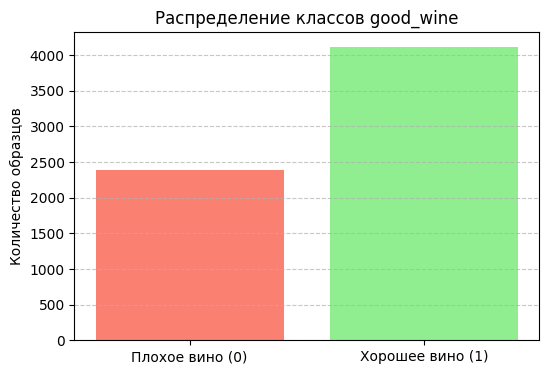

In [ ]:
# your code here
red_wine_data = pd.read_csv(r"D:\Repos\Data_analysis_with_Python\winequality-red.csv",sep = ";")
white_wine_data = pd.read_csv(r"D:\Repos\Data_analysis_with_Python\winequality-white.csv",sep = ";")

red_wine_data["Type"] = 0
white_wine_data["Type"] = 1

rw_data = pd.concat([red_wine_data,white_wine_data], ignore_index=True)

rw_data["good_wine"] =(rw_data["quality"] >= 6).astype(int)

class_counts = rw_data["good_wine"].value_counts().sort_index()
class_ratios = class_counts / len(rw_data)
print(class_counts)
print(class_ratios)
plt.figure(figsize=(6, 4))
plt.bar(["Плохое вино (0)", "Хорошее вино (1)"], class_counts, color=["salmon", "lightgreen"])
plt.title("Распределение классов good_wine")
plt.ylabel("Количество образцов")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### Задание 2. Логистическая регрессия (2 балла)

1. Отберите числовые признаки (кроме `quality`, `type` и `good_wine`). Разделите данные на обучающую (80%) и тестовую (20%) выборки, зафиксируйте `random_state`.

2. Выполните масштабирование признаков с помощью `StandardScaler`.

3. Обучите логистическую регрессию.

4. Постройте матрицу ошибок (confusion matrix) и выведите:

    - Accuracy
    - Precision
    - Recall

Train: 5197 образцов
Test:  1300 образцов
Confusion Matrix:
[[265 186]
 [170 679]]

Accuracy: 0.7262
Precision: 0.7850
Recall: 0.7998


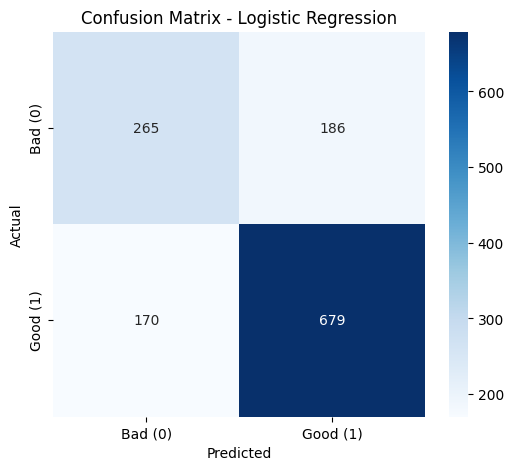

In [17]:
# your code here
features = [col for col in rw_data.columns if col not in ['quality', 'type', 'good_wine']]
X_wine = rw_data[features]
y_wine = rw_data['good_wine']

X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.20, random_state=42)
print(f"Train: {X_train.shape[0]} образцов")
print(f"Test:  {X_test.shape[0]} образцов")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

regression = LogisticRegression(random_state=42)
regression.fit(X_train_scaled, y_train)

y_pred = regression.predict(X_test_scaled)


cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Визуализация матрицы ошибок
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad (0)', 'Good (1)'], yticklabels=['Bad (0)', 'Good (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Дополнительно:

Ответьте на следующие вопросы:
- Какой тип ошибки (False Positive или False Negative) более опасен в задаче оценки качества вина для производителя?
- Для покупателя?  
- Как изменить порог классификации, чтобы минимизировать этот тип ошибки?

### Задание 3. ROC-кривая и AUC (1 балл)

1. Для обученной логистической регрессии получите вероятности принадлежности к классу 1 (`predict_proba`).
2. Постройте ROC-кривую.
3. Вычислите AUC (площадь под кривой) и интерпретируйте результат.
4. Сделайте вывод о качестве модели.

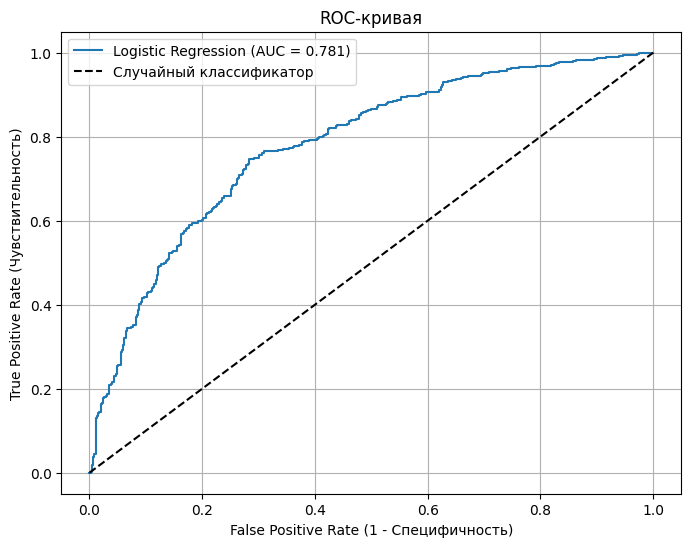

AUC = 0.781


In [ ]:
probs = regression.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, probs):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()

auc = roc_auc_score(y_test, probs)
print(f"AUC = {auc:.3f}")


### Задача 4. Анализ важности признаков (1 балл)

1. После обучения логистической регрессии изучите коэффициенты модели (помните, что признаки масштабированы).
2. Выведите признаки, которые увеличивают вероятность того, что вино хорошее (положительные коэффициенты, отсортированные по убыванию), и те, которые уменьшают (отрицательные, по возрастанию).
3. Постройте горизонтальную столбчатую диаграмму (barh) с отсортированными коэффициентами.

Коэффициенты логистической регрессии (после масштабирования):
  fixed acidity       : +0.167
  volatile acidity    : -0.805
  citric acid         : -0.098
  residual sugar      : +0.593
  chlorides           : -0.005
  free sulfur dioxide : +0.288
  total sulfur dioxide: -0.371
  density             : -0.398
  pH                  : +0.148
  sulphates           : +0.311
  alcohol             : +1.022
  Type                : -0.221


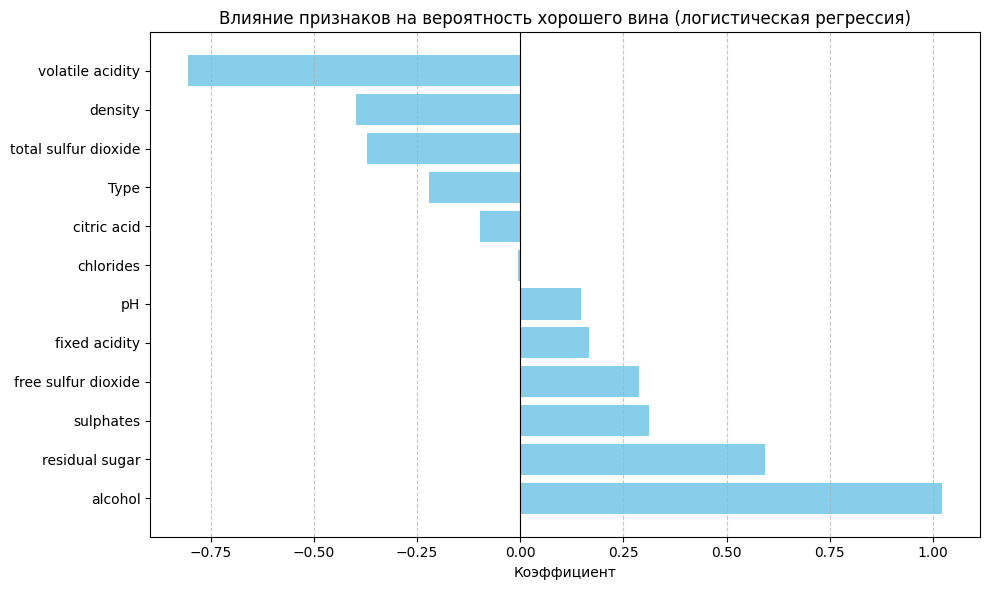

In [ ]:
# your code here

print("Коэффициенты логистической регрессии (после масштабирования):")
for name, coef in zip(features, regression.coef_[0]):    
    print(f"  {name:20s}: {coef:+.3f}")



coef_df = pd.DataFrame({'feature': features, 'coefficient': regression.coef_[0]})
coef_sorted = coef_df.sort_values('coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(coef_sorted['feature'], coef_sorted['coefficient'], color='skyblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент')
plt.title('Влияние признаков на вероятность хорошего вина (логистическая регрессия)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Дополнительно:

- Содержательно интерпретируйте 2–3 самых сильных признака: например, *«увеличение alcohol на одно стандартное отклонение повышает шансы на хорошее вино в X раз»*.
- Сравните с результами корреляционного анализа (df.corr).

### Задание 5. KNN (1 балл)

1. Используя те же масштабированные данные, обучите KNN с `n_neighbors=5` (Евклидово расстояние).
2. Вычислите accuracy, precision, recall и матрицу ошибок.
3. Сравните логистическую регрессию и KNN по метрикам. Какая модель лучше предсказывает? Почему?

Confusion Matrix:
[[265 186]
 [170 679]]
 KNN[[279 172]
 [157 692]]

Accuracy Linear: 0.7262, KNN: 0.7469
Precision Linear: 0.7850 KNN: 0.8009
Recall Linear: 0.7998 KNN: 0.8151


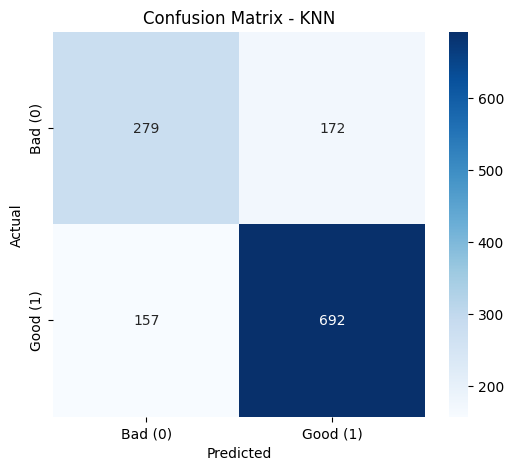

In [ ]:
# your code here
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Confusion Matrix:")
print(str(cm) + "\n KNN" +  str(cm_knn))
print(f"\nAccuracy Linear: {accuracy:.4f}, KNN: {accuracy_knn:.4f}")
print(f"Precision Linear: {precision:.4f} KNN: {precision_knn:.4f}")
print(f"Recall Linear: {recall:.4f} KNN: {recall_knn:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad (0)', 'Good (1)'], yticklabels=['Bad (0)', 'Good (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

Дополнительно:

- На практике обычно подбирают оптимальное k. Почему нельзя выбирать k по метрикам на тестовой выборке в реальном проекте?
- Что такое *data leakage* и как его избежать при подборе гиперпараметров?

### Задание 6. Кластеризация (2 балла)

1. Выберите 2-3 признака, которые, по вашему мнению, могут хорошо разделять вина на кластеры.
2. Перед кластеризацией обязательно масштабируйте выбранные признаки (StandardScaler), иначе признаки с большим масштабом будут доминировать.
3. Примените k-means с k=2.
4. Визуализируйте кластеры (scatterplot с цветами кластеров).
5. Сравните полученные кластеры с реальными метками `good_wine`. Постройте `pd.crosstab`

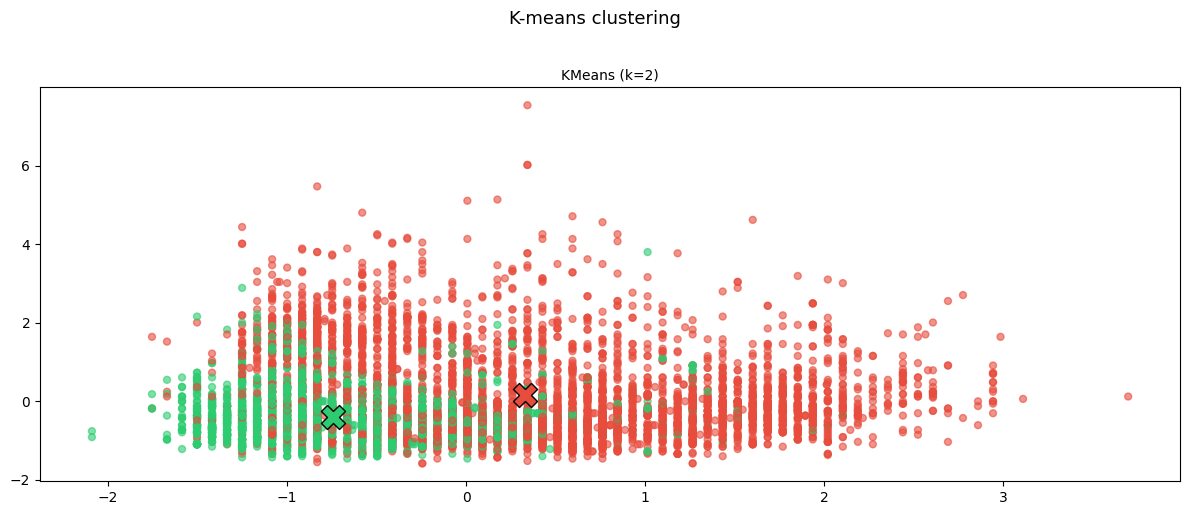

In [42]:
features = ["alcohol","volatile acidity", "residual sugar"]
X_cluster = rw_data[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

colors_1 = ['#e74c3c', '#2ecc71'] 
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

c_map = {j: colors_1[j] for j in range(2)}  
point_colors = [c_map[l] for l in clusters] 

axes.scatter(X_scaled[:, 0], X_scaled[:, 1], c=point_colors, s=25, alpha=0.6)
for j, center in enumerate(kmeans.cluster_centers_):
    axes.scatter(center[0], center[1], marker='X', s=300, c=colors_1[j], edgecolors='black', zorder=5)
axes.set_title('KMeans (k=2)', fontsize=10)  # изменил заголовок, но можно оставить "3 итерации" - не принципиально

plt.suptitle('K-means clustering', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Дополнительно:

- Добавьте метки кластеров в датафрейм. Сгруппируйте данные по кластерам и выведите средние значения признаков (всех числовых).
- Объясните, чем содержательно отличаются кластеры, какие признаки заметно отличаются.
- Вывод: насколько хорошо k-means разделил вино без учителя?

In [44]:
rw_data['cluster'] = kmeans.labels_ 

numeric_cols_all = rw_data.select_dtypes(include=['float64', 'int64']).columns
cluster_means = rw_data.groupby('cluster')[numeric_cols_all].mean()

print("Средние значения признаков по кластерам (k=2):")
print(cluster_means.round(2))

Средние значения признаков по кластерам (k=2):
         fixed acidity  volatile acidity  citric acid  residual sugar  \
cluster                                                                 
0                 7.34              0.37         0.31            2.84   
1                 6.93              0.27         0.35           11.35   

         chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
cluster                                                                        
0             0.06                25.38                 95.78     0.99  3.24   
1             0.05                42.20                161.06     1.00  3.16   

         sulphates  alcohol  quality  Type  good_wine  
cluster                                                
0             0.55    10.88     5.89  0.65       0.66  
1             0.49     9.61     5.66  0.99       0.57  


### Задание 7* (дополнительно). Красное vs белое: одна модель или две?

Гипотеза: модель, обученная только на красных винах, лучше предсказывает красные, чем модель, обученная на всём датасете.

1. Из обучающей выборки (X_train из задания 2) выделите только красные вина.
2. Из тестовой выборки (X_test, которая не использовалась при обучении общей модели) выделите только красные вина.
3. Обучите новую модель логистической регрессии только по красным винам, используйте масштабирование.
4. Оцените accuracy обеих моделей на этой тестовой выборке красных вин.
5. Постройте ROC-кривые обеих моделей на одном графике.
6. Сравните AUC и accuracy. Подтвердилась ли гипотеза? Когда имеет смысл сегментировать данные перед обучением?

Accuracy на красных винах (модель только на красных): 0.7449
Accuracy на красных винах (общая модель): 0.7331


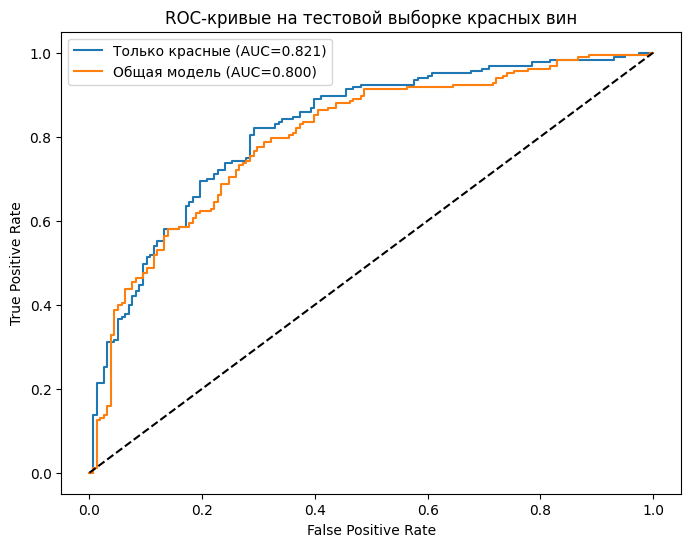

AUC только красные: 0.821
AUC общая модель: 0.800


In [49]:
# your code here
X_train_red = X_train[X_train['Type'] == 0]
y_train_red = y_train[X_train['Type'] == 0]
X_test_red = X_test[X_test['Type'] == 0]
y_test_red = y_test[X_test['Type'] == 0]


X_train_red_scaled = scaler.fit_transform(X_train_red)
X_test_red_scaled = scaler.transform(X_test_red)

logreg_red = LogisticRegression(random_state=42)
logreg_red.fit(X_train_red_scaled, y_train_red)


y_pred_global_red = regression.predict(X_test_red_scaled)
acc_global_red = accuracy_score(y_test_red, y_pred_global_red)

y_pred_red_red = logreg_red.predict(X_test_red_scaled)
acc_red_red = accuracy_score(y_test_red, y_pred_red_red)

print(f"Accuracy на красных винах (модель только на красных): {acc_red_red:.4f}")
print(f"Accuracy на красных винах (общая модель): {acc_global_red:.4f}")

probs_red = logreg_red.predict_proba(X_test_red_scaled)[:, 1]
probs_global = regression.predict_proba(X_test_red_scaled)[:, 1]

fpr_red, tpr_red, _ = roc_curve(y_test_red, probs_red)
fpr_global, tpr_global, _ = roc_curve(y_test_red, probs_global)
auc_red = roc_auc_score(y_test_red, probs_red)
auc_global = roc_auc_score(y_test_red, probs_global)

plt.figure(figsize=(8,6))
plt.plot(fpr_red, tpr_red, label=f'Только красные (AUC={auc_red:.3f})')
plt.plot(fpr_global, tpr_global, label=f'Общая модель (AUC={auc_global:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые на тестовой выборке красных вин')
plt.legend()
plt.show()

print(f"AUC только красные: {auc_red:.3f}")
print(f"AUC общая модель: {auc_global:.3f}")